# Analiza skupa podataka COVID-19

U ovom seminaru bavit ćemo se analizom i obradom skupa podataka o pandemiji COVID-19, koja je obilježila posljednje godine na globalnoj razini. COVID-19, bolest uzrokovana koronavirusom SARS-CoV-2, prvi je put identificiran u Wuhanu, Kini, krajem 2019. godine, te se brzo proširio svijetom, uzrokujući ozbiljne zdravstvene, ekonomske i socijalne posljedice.

Skup podataka s kojim ćemo raditi uključuje informacije o potvrđenim slučajevima zaraze, smrtnim ishodima, oporavcima, informacije koje nam mogu pomoći razumjeti dinamiku širenja virusa i učinkovitost mjera koje su različite zemlje poduzele u borbi protiv pandemije. Poseban naglasak stavit ćemo na analizu trendova širenja virusa, usporedbu situacije u hrvatskoj i Bsoni i Hercegovini.

Kroz seminar će se prikazati alat za obradu i analizu podataka, poput Pythona i njegovih biblioteka Pandas i Matplotlib, kako bi izvukli korisne informacije i vizualizirali podatke na razumljiv i informativan način.

Za početak je potrebno učitati potrebne biblioteke te dohvatiti podatke koje se nalaze u csv-u na linku "https://data.world/zathompson/covid-19-case-counts-test", te ih učitati u Pandas dataframe

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://query.data.world/s/a3jqck5jqo756iuifc55xtp2zqegyb?dws=00000')

Da bi smo povrdili da se dataframe valjano učitao, prvo ćemo ga isprintati, a zatim prikazati njegovih prvih 5 zapisa pomocu metode .head(), posljednih 5 zapisa pomoću metode .tail() i njegove informacije pomoću metode .info()

In [2]:
print(df)

        Case_Type  Cases  Difference       Date Country_Region Province_State  \
0       Confirmed    319           1  4/11/2020      Mauritius            NaN   
1          Deaths      0           0  2/27/2020        Bahamas            NaN   
2       Confirmed     16           0  2/16/2020        Germany            NaN   
3          Deaths      0           0  1/31/2020         Canada        Alberta   
4          Deaths      0           0   3/4/2020      Australia     Queensland   
...           ...    ...         ...        ...            ...            ...   
582655     Deaths      0           0  1/22/2020             US    Mississippi   
582656  Confirmed      0           0  1/22/2020             US        Alabama   
582657  Confirmed      0           0  1/22/2020             US      Tennessee   
582658     Deaths      0           0  1/22/2020             US      Louisiana   
582659     Deaths      0           0  1/22/2020             US     New Jersey   

            Admin2         

In [3]:
df.head()

,Case_Type,Cases,Difference,Date,Country_Region,Province_State,Admin2,Combined_Key,FIPS,Lat,Long,Table_Names,Prep_Flow_Runtime
0,Confirmed,319,1,4/11/2020,Mauritius,NaN,NaN,NaN,NaN,-20.2000,57.5000,Time Series,4/13/2020 9:18:41 PM
1,Deaths,0,0,2/27/2020,Bahamas,NaN,NaN,NaN,NaN,25.0343,-77.3963,Time Series,4/13/2020 9:18:41 PM
2,Confirmed,16,0,2/16/2020,Germany,NaN,NaN,NaN,NaN,51.0000,9.0000,Time Series,4/13/2020 9:18:41 PM
3,Deaths,0,0,1/31/2020,Canada,Alberta,NaN,NaN,NaN,53.9333,-116.5765,Time Series,4/13/2020 9:18:41 PM
4,Deaths,0,0,3/4/2020,Australia,Queensland,NaN,NaN,NaN,-28.0167,153.4000,Time Series,4/13/2020 9:18:41 PM


In [4]:
df.tail()

,Case_Type,Cases,Difference,Date,Country_Region,Province_State,Admin2,Combined_Key,FIPS,Lat,Long,Table_Names,Prep_Flow_Runtime
582655,Deaths,0,0,1/22/2020,US,Mississippi,Hancock,"Hancock, Mississippi, US",28045.0,30.418302,-89.488510,Time Series,4/13/2020 9:18:41 PM
582656,Confirmed,0,0,1/22/2020,US,Alabama,Etowah,"Etowah, Alabama, US",1055.0,34.045673,-86.040519,Time Series,4/13/2020 9:18:41 PM
582657,Confirmed,0,0,1/22/2020,US,Tennessee,Montgomery,"Montgomery, Tennessee, US",47125.0,36.496094,-87.385507,Time Series,4/13/2020 9:18:41 PM
582658,Deaths,0,0,1/22/2020,US,Louisiana,Lincoln,"Lincoln, Louisiana, US",22061.0,32.600315,-92.665974,Time Series,4/13/2020 9:18:41 PM
582659,Deaths,0,0,1/22/2020,US,New Jersey,Warren,"Warren, New Jersey, US",34041.0,40.859518,-74.995565,Time Series,4/13/2020 9:18:41 PM


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582660 entries, 0 to 582659
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Case_Type          582660 non-null  object 
 1   Cases              582660 non-null  int64  
 2   Difference         582660 non-null  int64  
 3   Date               582660 non-null  object 
 4   Country_Region     582660 non-null  object 
 5   Province_State     552780 non-null  object 
 6   Admin2             538836 non-null  object 
 7   Combined_Key       539666 non-null  object 
 8   FIPS               522402 non-null  float64
 9   Lat                582494 non-null  float64
 10  Long               582494 non-null  float64
 11  Table_Names        582660 non-null  object 
 12  Prep_Flow_Runtime  582660 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 57.8+ MB


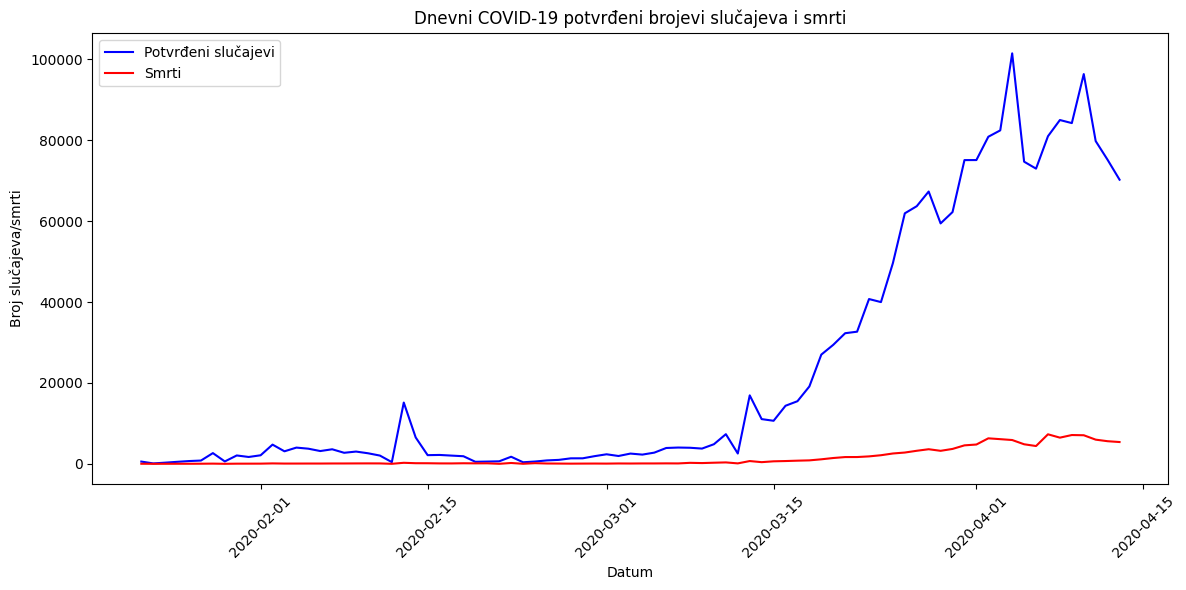

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

daily_totals = df.groupby(['Date', 'Case_Type'])['Difference'].sum().reset_index()

daily_confirmed = daily_totals[daily_totals['Case_Type'] == 'Confirmed']
daily_deaths = daily_totals[daily_totals['Case_Type'] == 'Deaths']

daily_confirmed.reset_index(drop=True, inplace=True)
daily_deaths.reset_index(drop=True, inplace=True)

daily_confirmed = daily_confirmed.sort_values('Date')
daily_deaths = daily_deaths.sort_values('Date')

plt.figure(figsize=(12, 6))
plt.plot(daily_confirmed['Date'], daily_confirmed['Difference'], label='Potvrđeni slučajevi', color='blue')
plt.plot(daily_deaths['Date'], daily_deaths['Difference'], label='Smrti', color='red')

plt.title('Dnevni COVID-19 potvrđeni brojevi slučajeva i smrti')
plt.xlabel('Datum')
plt.ylabel('Broj slučajeva/smrti')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
# Agregiranje podataka
total_by_country = df.groupby(['Country_Region', 'Case_Type'])['Difference'].sum().unstack()

sorted_infections = total_by_country['Confirmed'].sort_values(ascending=False)
sorted_deaths = total_by_country['Deaths'].sort_values(ascending=False)

first_highest_infections_country = sorted_infections.index[0]
second_highest_infections_country = sorted_infections.index[1]
third_highest_infections_country = sorted_infections.index[2]
forth_highest_infections_country = sorted_infections.index[3]
fifth_highest_infections_country = sorted_infections.index[4]

first_highest_deaths_country = sorted_deaths.index[0]
second_highest_deaths_country = sorted_deaths.index[1]
third_highest_deaths_country = sorted_deaths.index[2]
forth_highest_deaths_country = sorted_deaths.index[3]
fifth_highest_deaths_country = sorted_deaths.index[4]

print(f"Top 5 država s najvećim brojem infekcija:")
print(f"1.: {first_highest_infections_country} sa {sorted_infections.iloc[0]} slučajeva")
print(f"2.: {second_highest_infections_country} sa {sorted_infections.iloc[1]} slučajeva")
print(f"3.: {third_highest_infections_country} sa {sorted_infections.iloc[2]} slučajeva")
print(f"4.: {forth_highest_infections_country} sa {sorted_infections.iloc[3]} slučajeva")
print(f"5.: {fifth_highest_infections_country} sa {sorted_infections.iloc[4]} slučajeva")

print("\nTop 5 država po broju smrti:")
print(f"1.: {first_highest_deaths_country} sa {sorted_deaths.iloc[0]} smrti")
print(f"2.: {second_highest_deaths_country} sa {sorted_deaths.iloc[1]} smrti")
print(f"3.: {third_highest_deaths_country} sa {sorted_deaths.iloc[2]} smrti")
print(f"4.: {forth_highest_deaths_country} sa {sorted_deaths.iloc[3]} smrti")
print(f"5.: {fifth_highest_deaths_country} sa {sorted_deaths.iloc[4]} smrti")


Top 5 država s najvećim brojem infekcija:
1.: US sa 580071 slučajeva
2.: Spain sa 170099 slučajeva
3.: Italy sa 159516 slučajeva
4.: France sa 137875 slučajeva
5.: Germany sa 130072 slučajeva

Top 5 država po broju smrti:
1.: US sa 23520 smrti
2.: Italy sa 20465 smrti
3.: Spain sa 17756 smrti
4.: France sa 14986 smrti
5.: United Kingdom sa 11347 smrti


In [8]:
# Agregacija svih potvrđenih slučajeva po državi
totals_by_country = df.groupby('Country_Region').agg(
    Total_Confirmed=('Difference', lambda x: x[df['Case_Type'] == 'Confirmed'].sum()),
    Total_Deaths=('Difference', lambda x: x[df['Case_Type'] == 'Deaths'].sum())
).reset_index()

totals_by_country['Death_Percentage'] = (totals_by_country['Total_Deaths'] / totals_by_country['Total_Confirmed']) * 100

top_5_countries = totals_by_country.sort_values(by='Total_Confirmed', ascending=False).head(5)

top_5_countries[['Country_Region', 'Total_Confirmed', 'Total_Deaths', 'Death_Percentage']]


,Country_Region,Total_Confirmed,Total_Deaths,Death_Percentage
170,US,580071,23520,4.054676
155,Spain,170099,17756,10.438627
84,Italy,159516,20465,12.829434
61,France,137875,14986,10.869266
65,Germany,130072,3194,2.455563


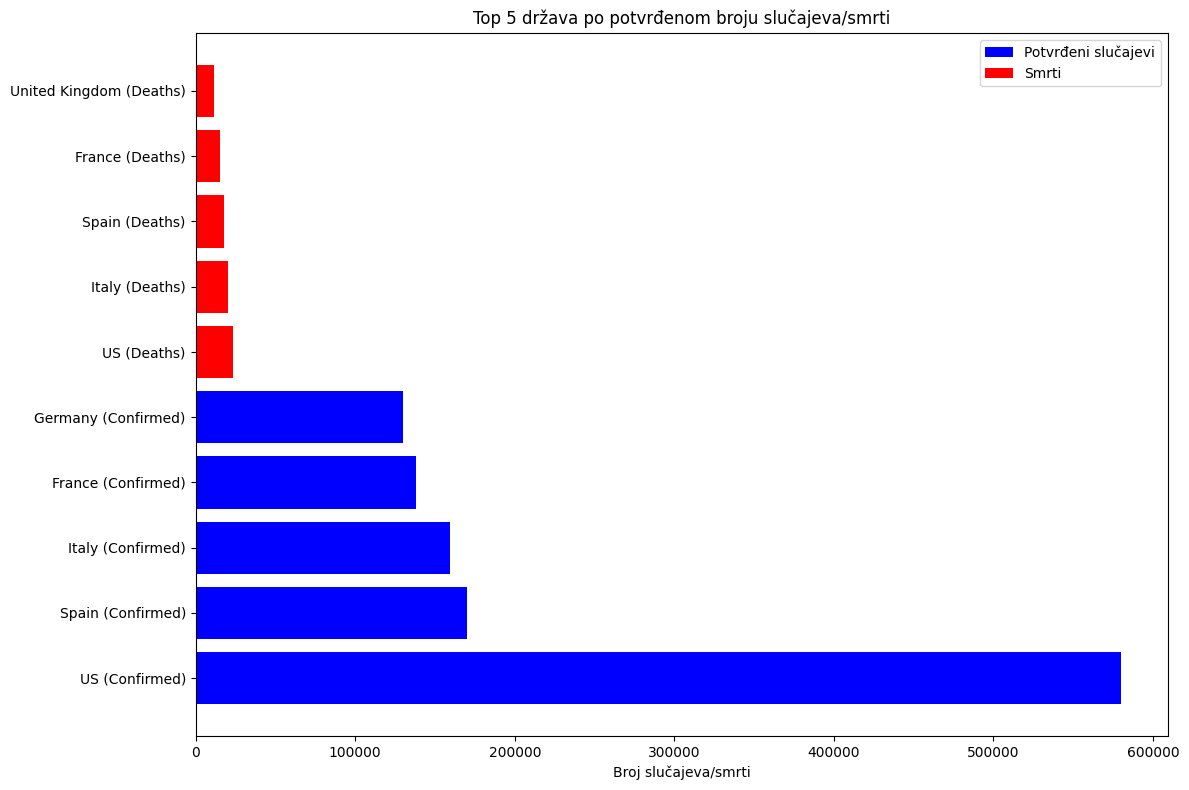

In [9]:
countries = [
    first_highest_infections_country,
    second_highest_infections_country,
    third_highest_infections_country,
    forth_highest_infections_country,
    fifth_highest_infections_country,
    first_highest_deaths_country,
    second_highest_deaths_country,
    third_highest_deaths_country,
    forth_highest_deaths_country,
    fifth_highest_deaths_country
]

cases = [
    sorted_infections.iloc[0],
    sorted_infections.iloc[1],
    sorted_infections.iloc[2],
    sorted_infections.iloc[3],
    sorted_infections.iloc[4],
    sorted_deaths.iloc[0],
    sorted_deaths.iloc[1],
    sorted_deaths.iloc[2],
    sorted_deaths.iloc[3],
    sorted_deaths.iloc[4]
]

case_types = ['Confirmed', 'Confirmed', 'Confirmed', 'Confirmed', 'Confirmed', 'Deaths', 'Deaths', 'Deaths', 'Deaths', 'Deaths']

plot_df = pd.DataFrame({
    'Country': countries,
    'Cases': cases,
    'Case_Type': case_types
})

fig, ax = plt.subplots(figsize=(12, 8))

confirmed_df = plot_df[plot_df['Case_Type'] == 'Confirmed']
deaths_df = plot_df[plot_df['Case_Type'] == 'Deaths']

ax.barh(confirmed_df['Country'] + " (Confirmed)", confirmed_df['Cases'], color='blue', label='Potvrđeni slučajevi')

ax.barh(deaths_df['Country'] + " (Deaths)", deaths_df['Cases'], color='red', label='Smrti')

ax.set_xlabel('Broj slučajeva/smrti')
ax.set_title('Top 5 država po potvrđenom broju slučajeva/smrti')
ax.legend()

plt.tight_layout()
plt.show()


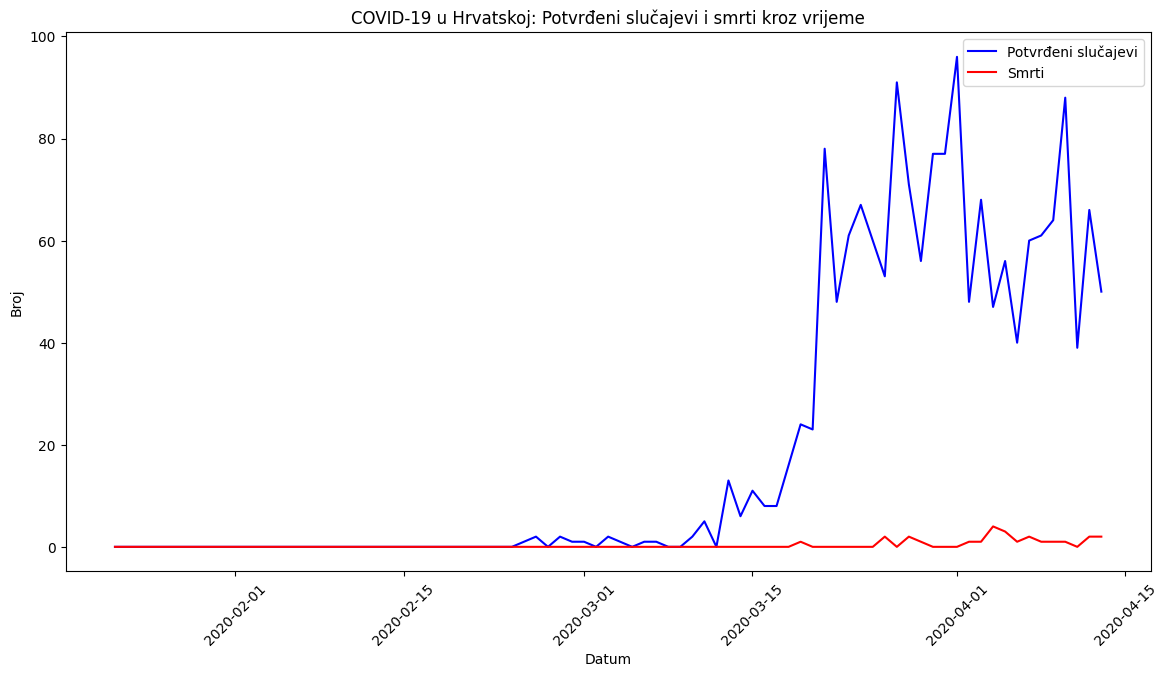

In [10]:
croatia_data = df[df['Country_Region'] == 'Croatia']

confirmed_cases_croatia = croatia_data[croatia_data['Case_Type'] == 'Confirmed'].sort_values(by='Date')
deaths_croatia = croatia_data[croatia_data['Case_Type'] == 'Deaths'].sort_values(by='Date')

plt.figure(figsize=(14, 7))

plt.plot(confirmed_cases_croatia['Date'], confirmed_cases_croatia['Difference'], label='Potvrđeni slučajevi', color='blue')

plt.plot(deaths_croatia['Date'], deaths_croatia['Difference'], label='Smrti', color='red')

plt.title('COVID-19 u Hrvatskoj: Potvrđeni slučajevi i smrti kroz vrijeme')
plt.xlabel('Datum')
plt.ylabel('Broj')
plt.legend()

plt.xticks(rotation=45)

plt.show()


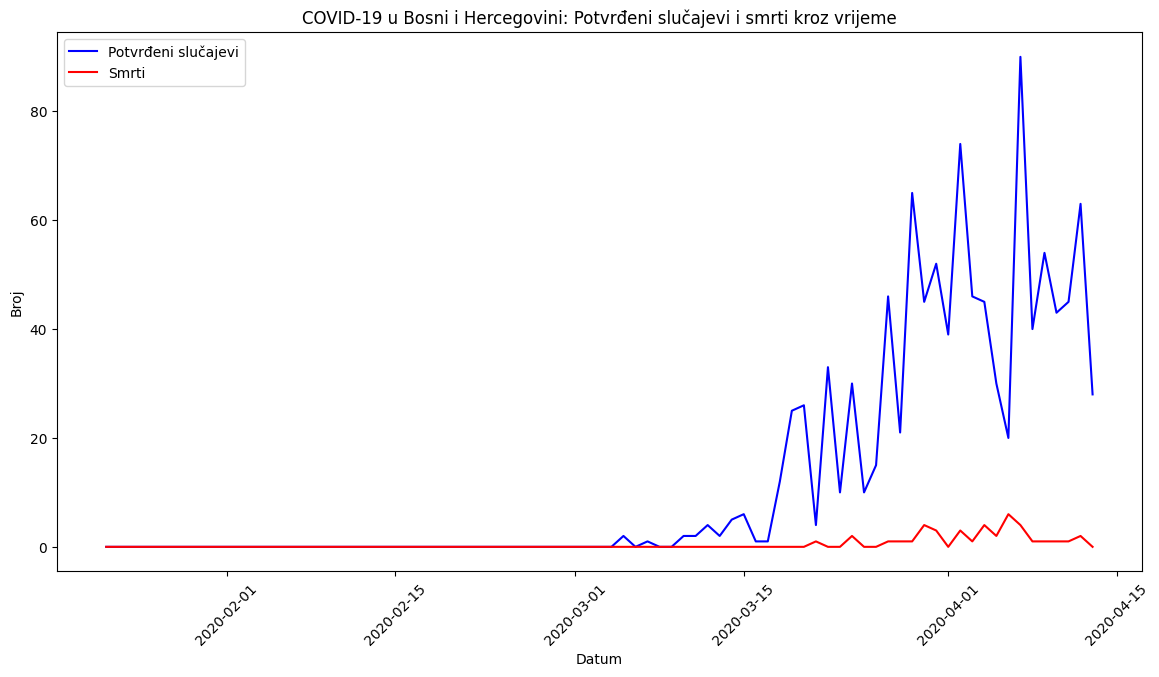

In [11]:
# Filtriranje podataka za BiH
bih_data = df[df['Country_Region'] == 'Bosnia and Herzegovina']

confirmed_cases_bih = bih_data[bih_data['Case_Type'] == 'Confirmed'].sort_values(by='Date')
deaths_bih = bih_data[bih_data['Case_Type'] == 'Deaths'].sort_values(by='Date')

plt.figure(figsize=(14, 7))

plt.plot(confirmed_cases_bih['Date'], confirmed_cases_bih['Difference'], label='Potvrđeni slučajevi', color='blue')

plt.plot(deaths_bih['Date'], deaths_bih['Difference'], label='Smrti', color='red')

plt.title('COVID-19 u Bosni i Hercegovini: Potvrđeni slučajevi i smrti kroz vrijeme')
plt.xlabel('Datum')
plt.ylabel('Broj')
plt.legend()

plt.xticks(rotation=45)

plt.show()


Sada ćemo usporediti podatke za Hrvatsku i Bosnu i Hercegovinu na jednom grafu

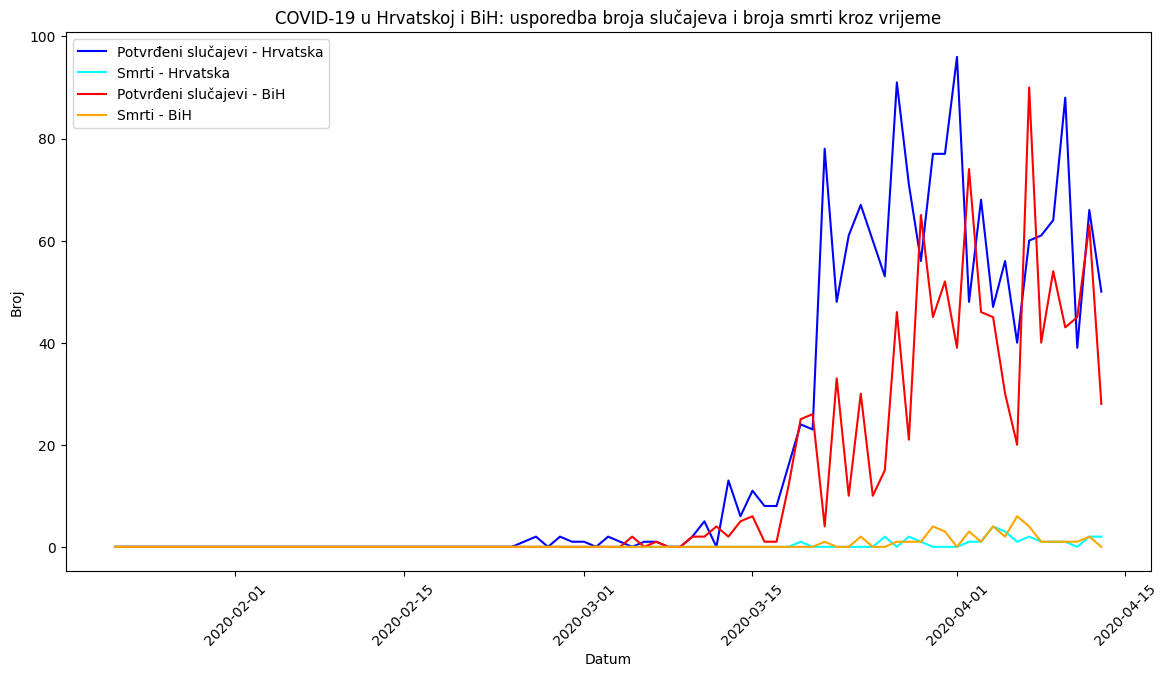

In [12]:
data_croatia = df[(df['Country_Region'] == 'Croatia')]
data_bosnia = df[(df['Country_Region'] == 'Bosnia and Herzegovina')]

confirmed_cases_croatia = data_croatia[data_croatia['Case_Type'] == 'Confirmed'].groupby('Date')['Difference'].sum()
deaths_croatia = data_croatia[data_croatia['Case_Type'] == 'Deaths'].groupby('Date')['Difference'].sum()

confirmed_cases_bosnia = data_bosnia[data_bosnia['Case_Type'] == 'Confirmed'].groupby('Date')['Difference'].sum()
deaths_bosnia = data_bosnia[data_bosnia['Case_Type'] == 'Deaths'].groupby('Date')['Difference'].sum()

plt.figure(figsize=(14, 7))

plt.plot(confirmed_cases_croatia.index, confirmed_cases_croatia, label='Potvrđeni slučajevi - Hrvatska', color='blue')
plt.plot(deaths_croatia.index, deaths_croatia, label='Smrti - Hrvatska', color='cyan')

plt.plot(confirmed_cases_bosnia.index, confirmed_cases_bosnia, label='Potvrđeni slučajevi - BiH', color='red')
plt.plot(deaths_bosnia.index, deaths_bosnia, label='Smrti - BiH', color='orange')


plt.title('COVID-19 u Hrvatskoj i BiH: usporedba broja slučajeva i broja smrti kroz vrijeme')
plt.xlabel('Datum')
plt.ylabel('Broj')
plt.legend()

plt.xticks(rotation=45)

plt.show()
